In [1]:
# @title Machine Learning Project
# Auteur : [Manar Lahouel & Oumayma Bayar]
# Description : Ce notebook guide l'utilisateur à travers les étapes de création d'un compte PhysioNet,
# de téléchargement de données et d'analyse d'un signal physiologique de base.

from IPython.display import HTML, display
import os

# Affichage du titre et du logo avec une URL PNG valide
display(HTML("""
<div style="display: flex; align-items: center; justify-content: center; border: 3px solid #2c6e9e; padding: 25px; text-align: center; background: linear-gradient(135deg, #f5f7fa 0%, #e9ecef 100%); border-radius: 15px; margin-bottom: 20px;">
    <img src="https://www.islah25.polytecsousse.tn/wp-content/uploads/2025/03/logo-polytechnique-300x150.png" width="200" style="margin-right: 25px; filter: drop-shadow(2px 2px 4px rgba(0,0,0,0.1));">
    <div>
        <h1 style="color: #1a73e8; font-size: 2.5em; margin: 0; font-weight: 600;">Project Machine Learning</h1>
        <p style="font-size: 1.2em; color: #5f6368; margin: 10px 0 0 0;">
            <strong>Sur Google Colab</strong> — Prediction of Diabetes Readmission Using Machine Learning
        </p>
    </div>
</div>
"""))

## ⚙️ Étape 1 — Configuration & Imports

Ce code importe les principales bibliothèques nécessaires pour un projet de Machine Learning.
Il inclut :

Pandas et NumPy pour la manipulation et le traitement des données
Matplotlib et Seaborn pour la visualisation
Scikit-learn pour :
le prétraitement des données (StandardScaler, LabelEncoder)
la division du dataset (train_test_split)
l’entraînement de plusieurs modèles de classification (Logistic Regression, Random Forest, KNN, etc.)
l’évaluation des performances (accuracy, F1-score, ROC, matrice de confusion)

Le code configure également l’environnement (suppression des warnings, paramètres graphiques) et garantit la reproductibilité des résultats avec random.seed

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from IPython.display import HTML, display

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Bibliothèques importées avec succès')


✅ Bibliothèques importées avec succès


## 📂 Étape 2 — Chargement des Données

Dans cette étape, les données sont importées à partir de fichiers CSV en utilisant la bibliothèque Pandas.
Le dataset principal (diabetic_data.csv) contient les informations des patients, tandis que le fichier (IDS_mapping.csv) fournit des correspondances utiles pour certaines variables.

Ensuite, on affiche :

les dimensions du dataset (nombre de lignes et colonnes),
la liste des variables,
et un aperçu des premières lignes avec head().

In [3]:
df = pd.read_csv('diabetic_data.csv')
ids_mapping = pd.read_csv('IDS_mapping.csv')

print(f"Dimensions du dataset : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Dimensions du dataset : (60788, 50)
Colonnes : ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 🔍 Étape 3 — Exploration des Données (EDA)

Cette étape permet d’obtenir une vue générale du dataset.
On affiche :

les informations générales avec info() (types de données, valeurs manquantes),
les statistiques descriptives avec describe() (moyenne, min, max, etc.),
la distribution de la variable cible readmitted (nombre et pourcentage de chaque classe).

Cela permet de mieux comprendre la structure des données et d’identifier d’éventuels déséquilibres.

In [4]:
# Informations générales
print('=' * 15)
print('INFORMATIONS GÉNÉRALES')
print('=' * 15)
print(df.info())
print('\nStatistiques descriptives :')
print(df.describe())

print('\nDistribution de readmitted :')
print(df['readmitted'].value_counts())
print(f'\nPourcentages :')
print((df['readmitted'].value_counts(normalize=True) * 100).round(2))


INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60788 entries, 0 to 60787
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              60788 non-null  int64 
 1   patient_nbr               60788 non-null  int64 
 2   race                      60788 non-null  object
 3   gender                    60788 non-null  object
 4   age                       60788 non-null  object
 5   weight                    60788 non-null  object
 6   admission_type_id         60788 non-null  int64 
 7   discharge_disposition_id  60788 non-null  int64 
 8   admission_source_id       60788 non-null  int64 
 9   time_in_hospital          60788 non-null  int64 
 10  payer_code                60788 non-null  object
 11  medical_specialty         60788 non-null  object
 12  num_lab_procedures        60788 non-null  int64 
 13  num_procedures            60788 non-null  int64 
 14 

Cette étape analyse la répartition de la variable cible readmitted.
On affiche le nombre d’occurrences de chaque classe ainsi que leurs pourcentages.

Cela permet d’identifier si les données sont équilibrées ou déséquilibrées, ce qui est important pour le choix et l’évaluation des modèles de classification.

In [5]:
#Distribution de la variable cible
print("Distribution de 'readmitted':")
print(df['readmitted'].value_counts())
print(f"\nPourcentages:")
print(df['readmitted'].value_counts(normalize=True).round(3) * 100)

Distribution de 'readmitted':
readmitted
NO     32166
>30    21663
<30     6958
Name: count, dtype: int64

Pourcentages:
readmitted
NO     52.9
>30    35.6
<30    11.4
Name: proportion, dtype: float64


Cette étape permet de visualiser la distribution des données et de mieux comprendre les relations entre les variables.

Quatre graphiques sont générés :

Distribution de la variable cible (readmitted) : un diagramme en secteurs montre la répartition des classes.
Réadmission par genre : un diagramme en barres compare les cas de réadmission entre hommes et femmes.
Durée d’hospitalisation vs réadmission : un histogramme analyse la relation entre le temps passé à l’hôpital et la réadmission.
Nombre de médicaments vs réadmission : un histogramme étudie l’impact du nombre de médicaments prescrits.

Ces visualisations permettent d’identifier des tendances et des relations importantes dans les données avant la phase de modélisation.

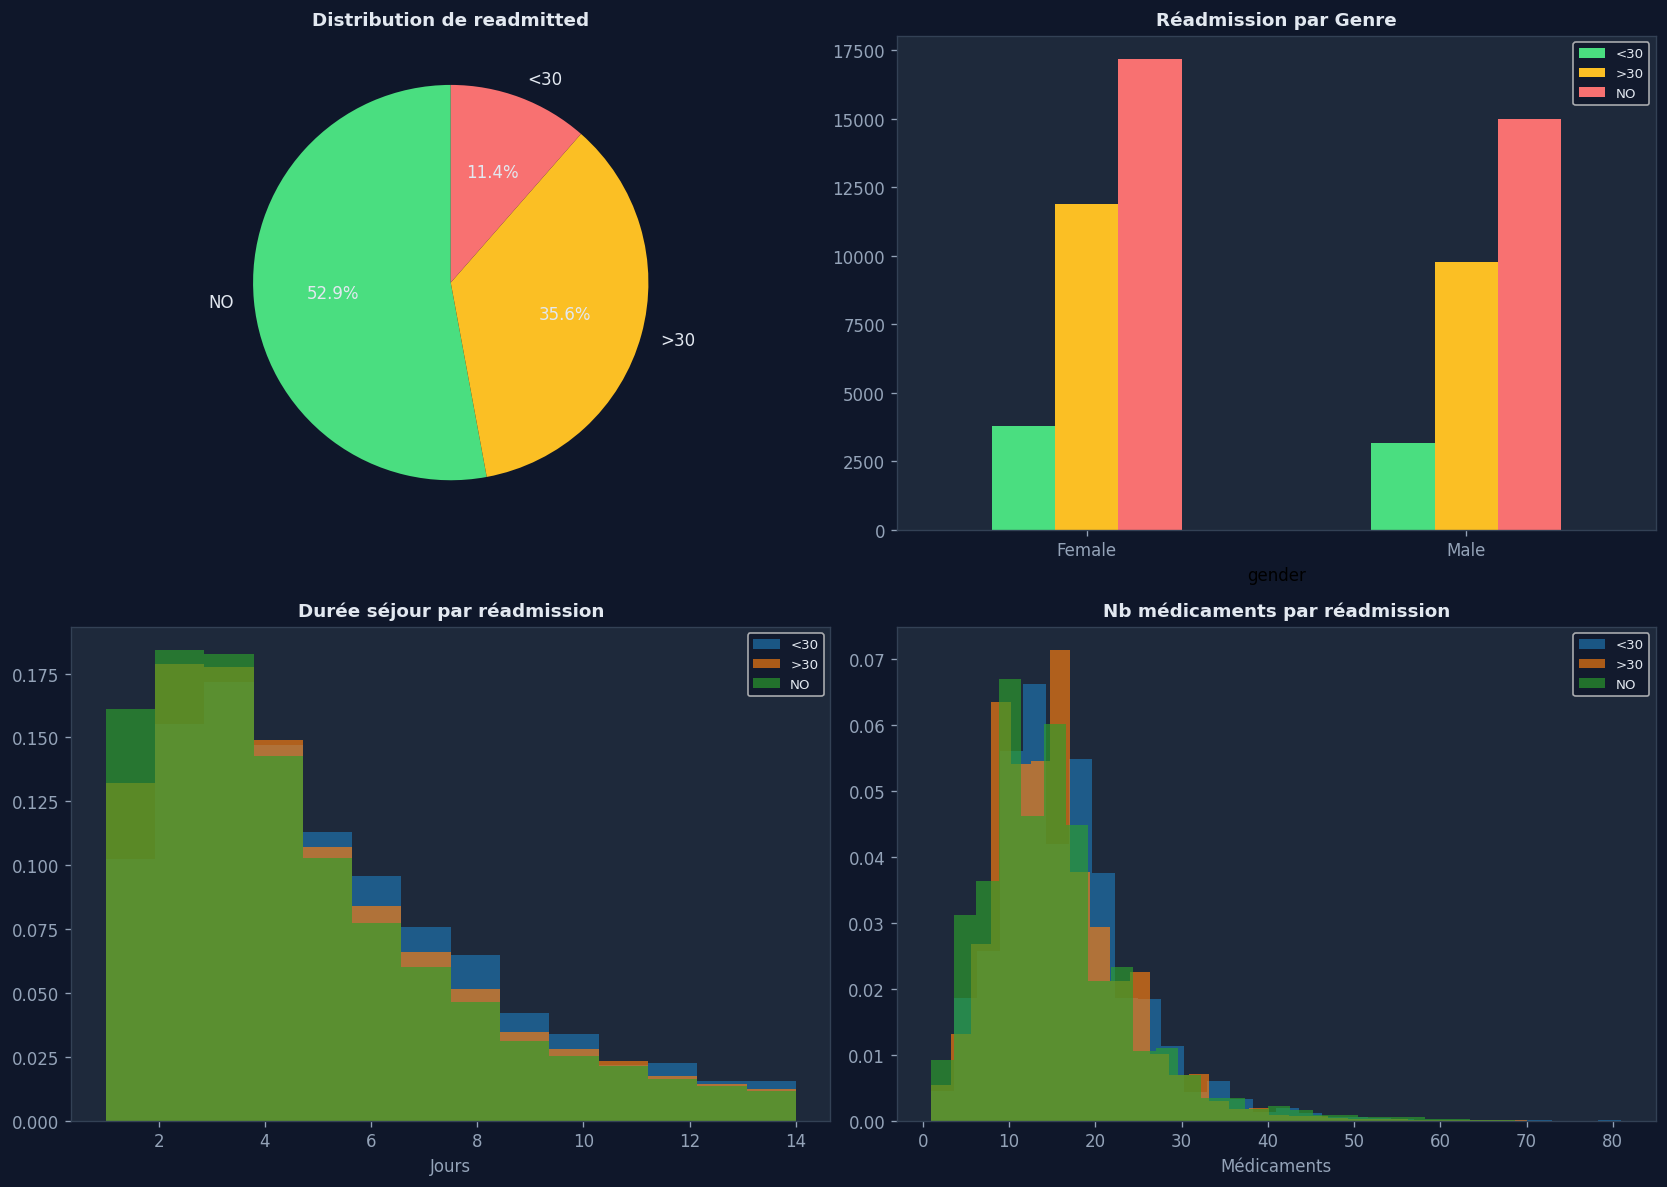

In [6]:
# ── Visualisation EDA ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f172a')
for ax in axes.flat:
    ax.set_facecolor('#1e293b')

C_MUTED = '#94a3b8'; C_TEXT = '#e2e8f0'

# 1. Distribution cible
counts = df['readmitted'].value_counts()
colors_pie = ['#4ade80', '#fbbf24', '#f87171']
axes[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%',
              colors=colors_pie, startangle=90,
              textprops={'color': C_TEXT, 'fontsize': 10})
axes[0,0].set_title('Distribution de readmitted', color=C_TEXT, fontsize=11, fontweight='bold')

# 2. Réadmission par genre
df_g = df[df['gender'].isin(['Male','Female'])]
g_r = df_g.groupby(['gender','readmitted']).size().unstack(fill_value=0)
g_r.plot(kind='bar', ax=axes[0,1], color=['#4ade80','#fbbf24','#f87171'])
axes[0,1].set_title('Réadmission par Genre', color=C_TEXT, fontsize=11, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0, colors=C_MUTED)
axes[0,1].tick_params(axis='y', colors=C_MUTED)
axes[0,1].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

# 3. Durée séjour vs réadmission
for label, grp in df.groupby('readmitted')['time_in_hospital']:
    axes[1,0].hist(grp, bins=14, alpha=0.65, label=label, density=True)
axes[1,0].set_title('Durée séjour par réadmission', color=C_TEXT, fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Jours', color=C_MUTED)
axes[1,0].tick_params(colors=C_MUTED)
axes[1,0].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

# 4. Médicaments vs réadmission
for label, grp in df.groupby('readmitted')['num_medications']:
    axes[1,1].hist(grp, bins=30, alpha=0.65, label=label, density=True)
axes[1,1].set_title('Nb médicaments par réadmission', color=C_TEXT, fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Médicaments', color=C_MUTED)
axes[1,1].tick_params(colors=C_MUTED)
axes[1,1].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

for ax in axes.flat:
    for sp in ax.spines.values(): sp.set_edgecolor('#334155')

plt.tight_layout()
plt.show()


---
## 🧹 Étape 4 — Nettoyage des Données

Dans cette étape, les valeurs manquantes sont d’abord uniformisées en remplaçant le symbole "?" par NaN (valeur manquante reconnue par Pandas).

Ensuite, une analyse est effectuée pour :

compter le nombre de valeurs manquantes par colonne,
calculer leur pourcentage,
identifier les colonnes les plus affectées,
afficher uniquement les variables contenant des valeurs manquantes.

Cela permet de mieux préparer les données avant l’étape de prétraitement et de modélisation.

In [7]:
df.replace('?', np.nan, inplace=True)

# Valeurs manquantes
total = len(df)
missing = df.isnull().sum()
pct = (missing / total * 100).round(2)
result = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': pct})
result = result[result['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)
print('Colonnes avec valeurs manquantes :')
print(result)


Colonnes avec valeurs manquantes :
                          Manquants  Pourcentage (%)
weight                        58697            96.56
max_glu_serum                 56011            92.14
A1Cresult                     51505            84.73
payer_code                    35748            58.81
medical_specialty             23566            38.77
race                           1304             2.15
diag_3                         1184             1.95
diag_2                          289             0.48
diag_1                           15             0.02
metformin                         1             0.00
repaglinide                       1             0.00
nateglinide                       1             0.00
chlorpropamide                    1             0.00
glimepiride                       1             0.00
acetohexamide                     1             0.00
glipizide                         1             0.00
glyburide                         1             0.00
tolbutamide

Cette étape consiste à améliorer la qualité des données avant la modélisation.

Certaines colonnes jugées non pertinentes ou peu informatives sont supprimées (ex : identifiants, variables médicales peu utiles).
Les valeurs manquantes sont ensuite traitées :
Pour les variables numériques, elles sont remplacées par la médiane.
Pour les variables catégorielles, elles sont remplacées par la valeur la plus fréquente (mode).

Enfin, on vérifie qu’il ne reste plus de valeurs manquantes et on affiche la nouvelle dimension du dataset après nettoyage.

In [8]:
# ── Suppression colonnes inutiles ───────────────────────────
cols_drop = ['weight', 'max_glu_serum', 'A1Cresult',
             'encounter_id', 'patient_nbr', 'examide', 'citoglipton']
cols_drop_exist = [c for c in cols_drop if c in df.columns]
df.drop(columns=cols_drop_exist, inplace=True)
print(f'✅ Colonnes supprimées : {cols_drop_exist}')

# ── Remplissage valeurs manquantes ───────────────────────────
# Numérique → médiane | Catégoriel → mode
for col in df.columns[df.isnull().sum() > 0]:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
        print(f'[NUMÉRIQUE]   {col} → médiane = {df[col].median():.1f}')
    else:
        val = df[col].mode()[0]
        df[col] = df[col].fillna(val)
        print(f'[CATÉGORIEL]  {col} → mode = "{val}"')

print(f'\n✅ Valeurs manquantes restantes : {df.isnull().sum().sum()}')
print(f'Dimensions après nettoyage : {df.shape}')


✅ Colonnes supprimées : ['weight', 'max_glu_serum', 'A1Cresult', 'encounter_id', 'patient_nbr', 'examide', 'citoglipton']
[CATÉGORIEL]  race → mode = "Caucasian"
[CATÉGORIEL]  payer_code → mode = "MC"
[CATÉGORIEL]  medical_specialty → mode = "InternalMedicine"
[CATÉGORIEL]  diag_1 → mode = "414"
[CATÉGORIEL]  diag_2 → mode = "428"
[CATÉGORIEL]  diag_3 → mode = "250"
[CATÉGORIEL]  metformin → mode = "No"
[CATÉGORIEL]  repaglinide → mode = "No"
[CATÉGORIEL]  nateglinide → mode = "No"
[CATÉGORIEL]  chlorpropamide → mode = "No"
[CATÉGORIEL]  glimepiride → mode = "No"
[CATÉGORIEL]  acetohexamide → mode = "No"
[CATÉGORIEL]  glipizide → mode = "No"
[CATÉGORIEL]  glyburide → mode = "No"
[CATÉGORIEL]  tolbutamide → mode = "No"
[CATÉGORIEL]  pioglitazone → mode = "No"
[CATÉGORIEL]  rosiglitazone → mode = "No"
[CATÉGORIEL]  acarbose → mode = "No"
[CATÉGORIEL]  miglitol → mode = "No"
[CATÉGORIEL]  troglitazone → mode = "No"
[CATÉGORIEL]  tolazamide → mode = "No"
[CATÉGORIEL]  insulin → mode = "No"

---
## 🎯 Étape 5 — Binarisation de la Variable Cible

Dans cette étape, la variable cible readmitted est transformée en une variable binaire pour simplifier le problème de classification :

1 : patient réadmis en moins de 30 jours (cas critique)
0 : autre cas (non réadmis ou réadmis après 30 jours)

Ensuite, la variable originale est supprimée et la nouvelle distribution est analysée pour vérifier le déséquilibre des classes.

Distribution cible binaire :
readmitted_bin
0    53830
1     6958
Name: count, dtype: int64

Taux réadmission <30j : 11.45%


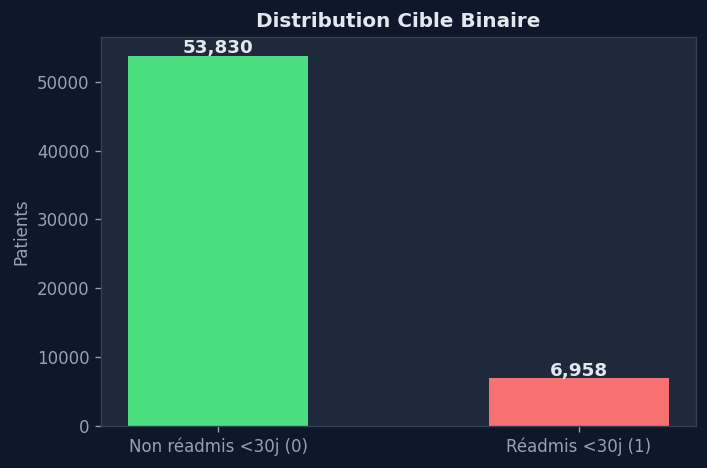

In [9]:
# 1 = réadmis < 30j (cas critique) | 0 = sinon
df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print('Distribution cible binaire :')
print(df['readmitted_bin'].value_counts())
print(f'\nTaux réadmission <30j : {df["readmitted_bin"].mean():.2%}')

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#1e293b')
bars = ax.bar(['Non réadmis <30j (0)', 'Réadmis <30j (1)'],
              df['readmitted_bin'].value_counts().sort_index(),
              color=['#4ade80', '#f87171'], width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+300,
            f'{int(b.get_height()):,}', ha='center', fontsize=11,
            fontweight='bold', color='#e2e8f0')
ax.set_title('Distribution Cible Binaire', color='#e2e8f0', fontsize=12, fontweight='bold')
ax.set_ylabel('Patients', color='#94a3b8')
ax.tick_params(colors='#94a3b8')
for sp in ax.spines.values(): sp.set_edgecolor('#334155')
plt.tight_layout(); plt.show()


---
## 🔢 Étape 6 — Encodage des Variables Catégorielles

Dans cette étape, les variables catégorielles sont transformées en valeurs numériques afin de pouvoir être utilisées par les algorithmes de Machine Learning.

Les colonnes de type object sont automatiquement identifiées.
Chaque variable catégorielle est encodée à l’aide de LabelEncoder, qui attribue un code numérique à chaque catégorie.
Les encodeurs sont sauvegardés pour une éventuelle réutilisation (ex : prédiction future)

In [10]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
# Only use 'object' here to capture string/mixed columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Colonnes catégorielles à encoder ({len(cat_cols)}) :')
print(cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    # Convert to str here is fine to ensure no mixed types break the encoder
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = [c for c in df.columns if c != 'readmitted_bin']
print(f'\n✅ Encodage terminé — {len(feature_cols)} features finales')
print(f'Dimensions finales : {df.shape}')

Colonnes catégorielles à encoder (31) :
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

✅ Encodage terminé — 42 features finales
Dimensions finales : (60788, 43)


---
## ✂️ Étape 7 — Train / Test Split

Dans cette étape, le dataset est séparé en variables explicatives (X) et variable cible (y).

Ensuite, les données sont divisées en deux ensembles :

80% pour l’entraînement (train)
20% pour le test

La séparation est effectuée avec stratify=y afin de conserver la même distribution de la variable cible dans les deux ensembles.

In [11]:
X = df[feature_cols]
y = df['readmitted_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Taux cible Train : {y_train.mean():.2%}')
print(f'Taux cible Test  : {y_test.mean():.2%}')


Train : (48630, 42)  |  Test : (12158, 42)
Taux cible Train : 11.45%
Taux cible Test  : 11.45%


---
## 🤖 Étape 8 — Pipeline : StandardScaler + Random Forest

Dans cette étape, un pipeline de Machine Learning est construit afin d’automatiser le prétraitement et l’entraînement du modèle.

Le pipeline contient deux étapes principales :

StandardScaler : normalisation des variables pour améliorer les performances du modèle.
RandomForestClassifier : algorithme d’ensemble utilisé pour la classification, configuré avec :
100 arbres (n_estimators=100)
profondeur maximale de 15 (max_depth=15)
gestion du déséquilibre des classes (class_weight='balanced')

Ensuite, le modèle est entraîné sur les données d’apprentissage (X_train, y_train), et le temps d’exécution est mesuré afin d’évaluer les performances du processus d’entraînement.

In [12]:
from sklearn.preprocessing import LabelEncoder
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print('⏳ Entraînement en cours...')
t0 = time.time()
pipeline.fit(X_train, y_train)
print(f'✅ Entraîné en {time.time()-t0:.1f}s')


⏳ Entraînement en cours...
✅ Entraîné en 7.2s


---
## ⚖️ Étape 9 — Comparaison de 3 Modèles

Cette étape consiste à comparer trois modèles de classification : Logistic Regression, Random Forest et KNN.

Chaque modèle est entraîné dans un pipeline avec normalisation des données, puis évalué sur le jeu de test à l’aide du F1-score et de l’accuracy, ainsi que du temps d’exécution.

Les résultats sont ensuite regroupés dans un tableau et visualisés pour identifier le modèle le plus performant.

Logistic Regression       → Train:0.8856 | Test:0.8844 | 0.22s
Random Forest             → Train:0.9999 | Test:0.8861 | 13.27s
KNN (k=5)                 → Train:0.8911 | Test:0.8777 | 0.05s


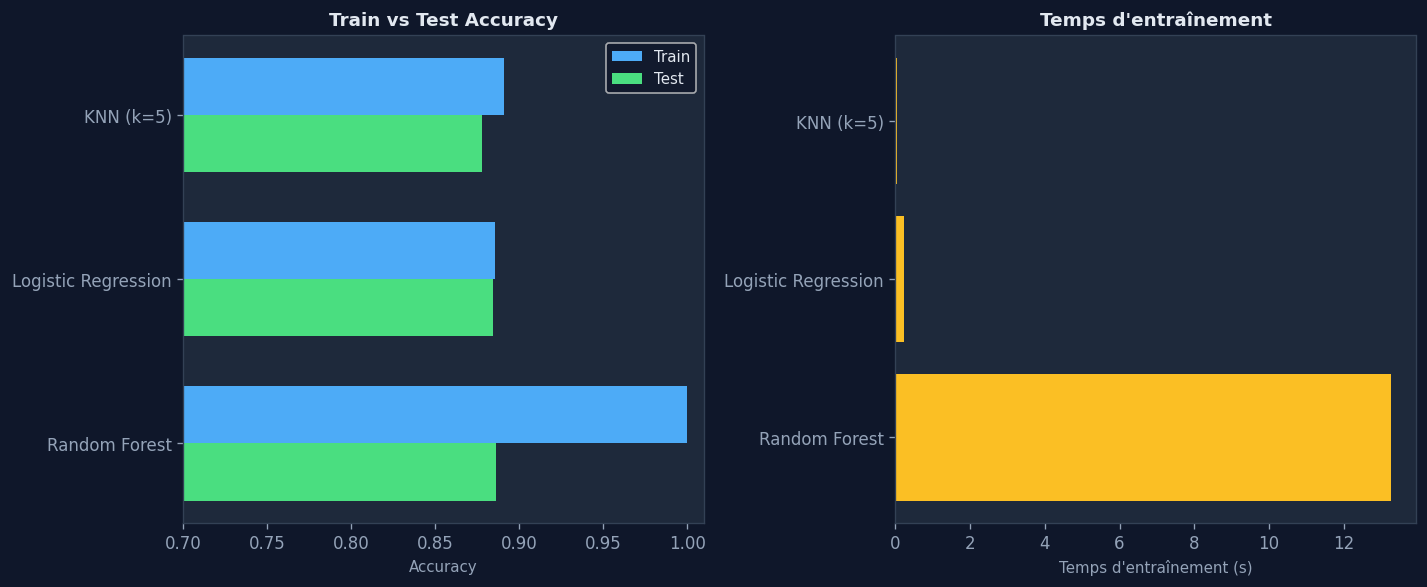


🏆 Meilleur modèle : Random Forest
   Test Accuracy  : 0.8861
   Temps          : 13.27s

              Modèle  Train   Test  Temps(s)
      Random Forest 0.9999 0.8861     13.27
Logistic Regression 0.8856 0.8844      0.22
          KNN (k=5) 0.8911 0.8777      0.05


In [13]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# ── Seulement les 3 modèles sélectionnés ─────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
}

results_cmp = []
for name, model in models.items():
    t0   = time.time()
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    dur  = round(time.time()-t0, 2)
    atr  = accuracy_score(y_train, pipe.predict(X_train))
    ate  = accuracy_score(y_test,  pipe.predict(X_test))
    results_cmp.append({'Modèle':name,'Train':round(atr,4),'Test':round(ate,4),'Temps(s)':dur})
    print(f'{name:25s} → Train:{atr:.4f} | Test:{ate:.4f} | {dur}s')

cmp_df = pd.DataFrame(results_cmp).sort_values('Test', ascending=False)

# ── Visualisation comparaison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f172a')
for ax in axes: ax.set_facecolor('#1e293b')

axes[0].barh(cmp_df['Modèle'], cmp_df['Train'],
             height=0.35, label='Train', color='#4dabf7', align='edge')
axes[0].barh(cmp_df['Modèle'], cmp_df['Test'],
             height=-0.35, label='Test', color='#4ade80', align='edge')
axes[0].set_xlabel('Accuracy', color='#94a3b8', fontsize=9)
axes[0].set_title('Train vs Test Accuracy', color='#e2e8f0', fontsize=11, fontweight='bold')
axes[0].legend(facecolor='#0f172a', labelcolor='#e2e8f0', fontsize=9)
axes[0].set_xlim(0.7, 1.01)
axes[0].tick_params(colors='#94a3b8')
for sp in axes[0].spines.values(): sp.set_edgecolor('#334155')

axes[1].barh(cmp_df['Modèle'], cmp_df['Temps(s)'], color='#fbbf24')
axes[1].set_xlabel("Temps d'entraînement (s)", color='#94a3b8', fontsize=9)
axes[1].set_title("Temps d'entraînement", color='#e2e8f0', fontsize=11, fontweight='bold')
axes[1].tick_params(colors='#94a3b8')
for sp in axes[1].spines.values(): sp.set_edgecolor('#334155')

plt.tight_layout(); plt.show()

best = cmp_df.iloc[0]
print(f'\n🏆 Meilleur modèle : {best["Modèle"]}')
print(f'   Test Accuracy  : {best["Test"]}')
print(f'   Temps          : {best["Temps(s)"]}s')
print('\n', cmp_df.to_string(index=False))

---
## 📊 Étape 10 — Évaluation Complète & Dashboard Matplotlib


Cette étape permet d’évaluer en détail les performances du modèle Random Forest sur le jeu de test.

Plusieurs métriques sont calculées :

Accuracy sur les données d’entraînement et de test
AUC-ROC pour mesurer la qualité globale de classification
F1-score pour équilibrer précision et rappel
Average Precision pour évaluer les performances sur les classes déséquilibrées

Un dashboard visuel est ensuite généré, comprenant :

les métriques principales (KPI)
la matrice de confusion
la courbe ROC
la distribution des probabilités
la courbe précision-rappel
l’importance des variables (Top features)

Enfin, un classification report est affiché pour résumer les performances du modèle sur chaque classe.

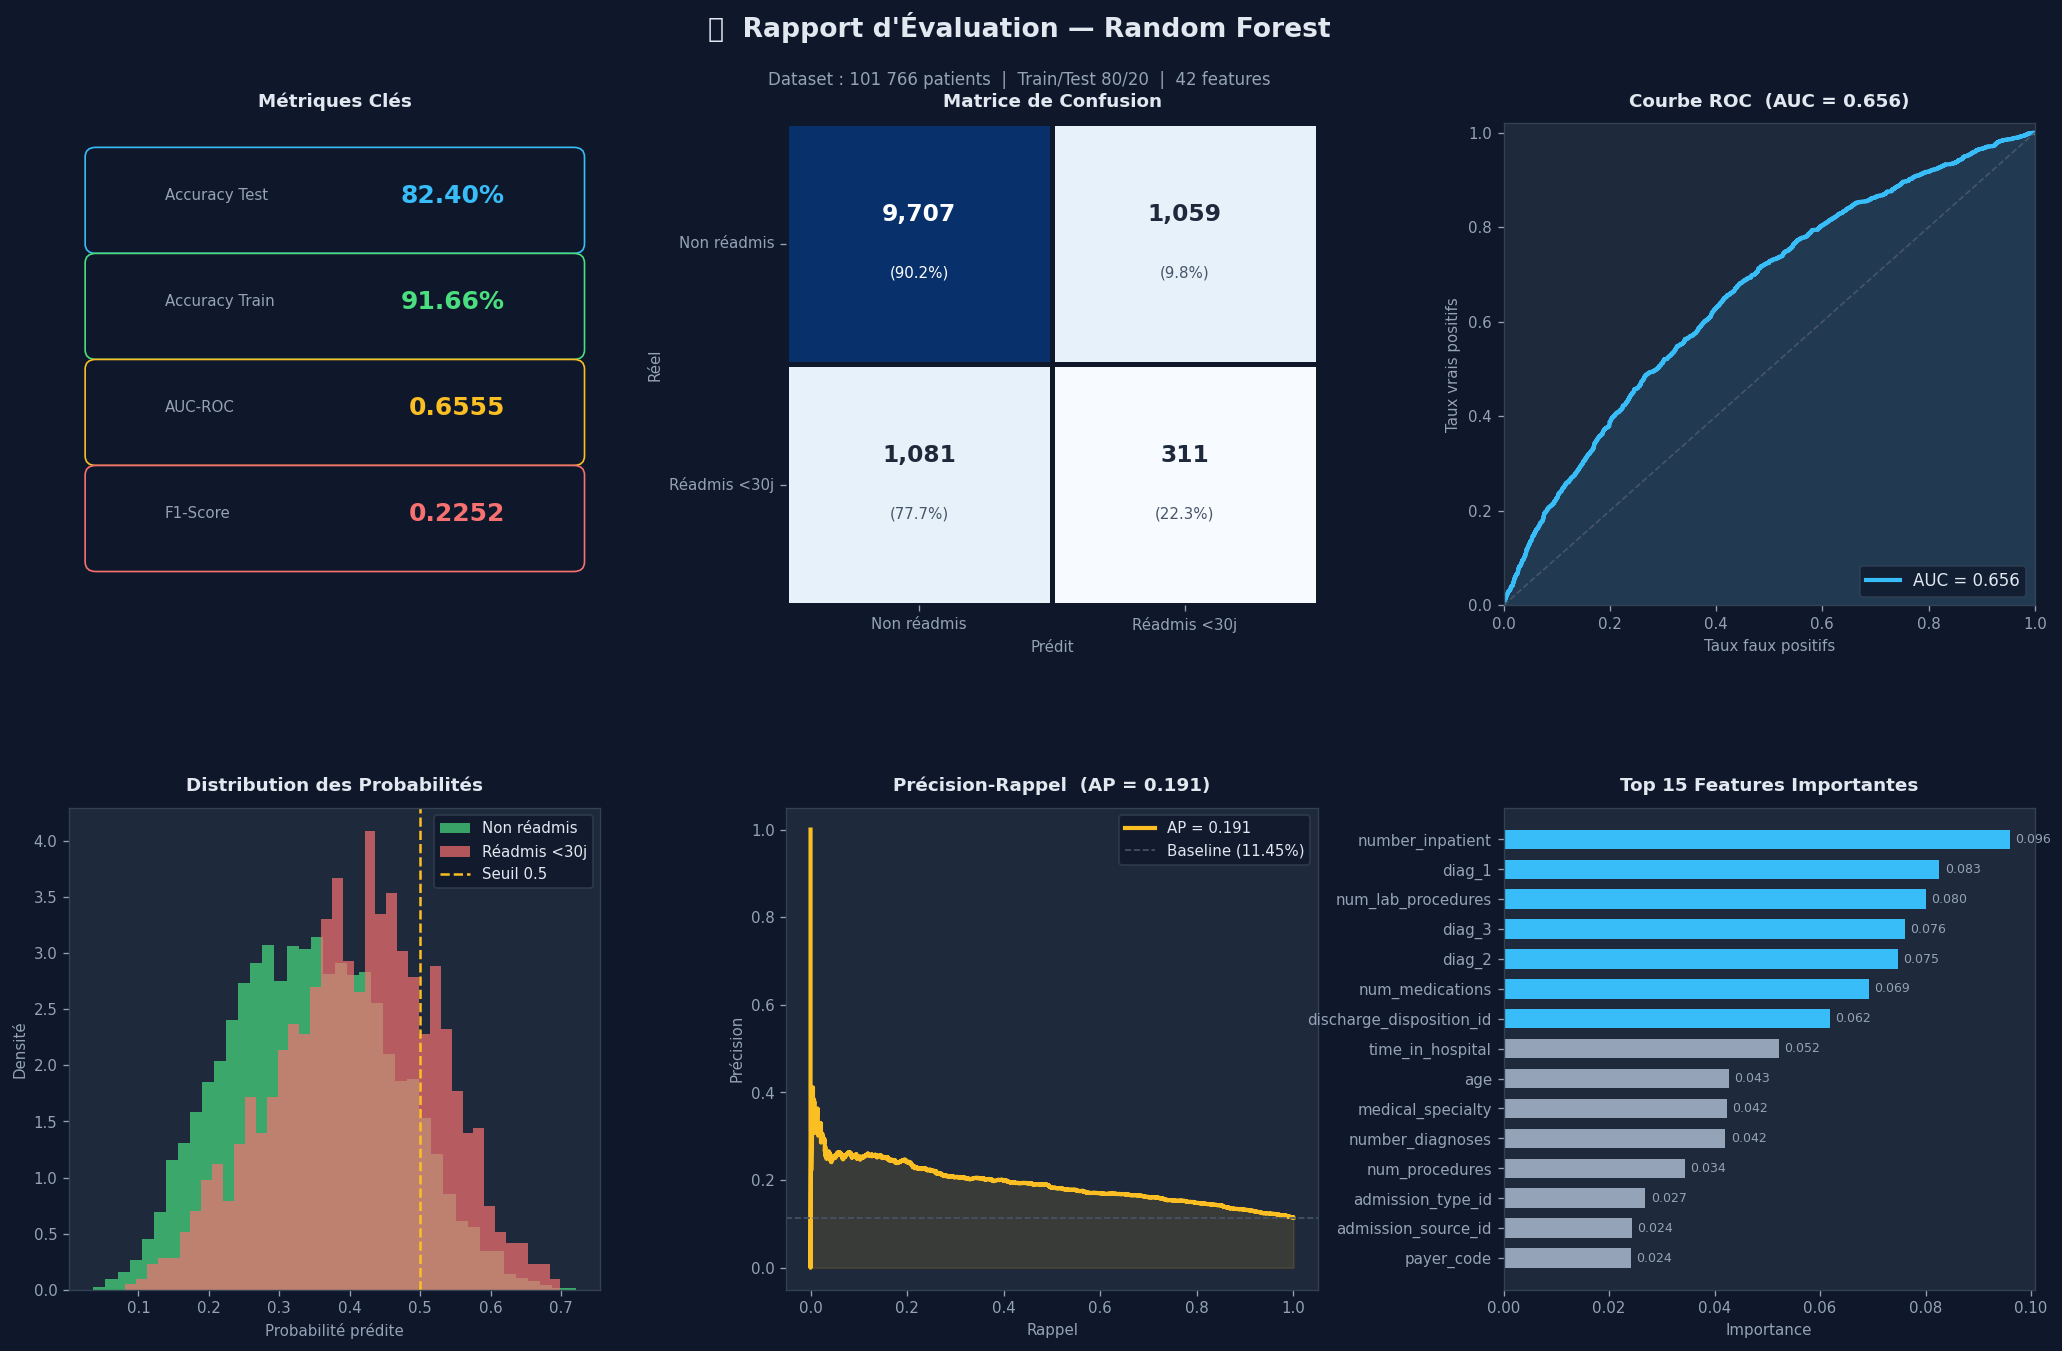


═══════════════════════════════════════════════════════
  Accuracy Train : 0.9166
  Accuracy Test  : 0.8240
  AUC-ROC        : 0.6555
  F1-Score       : 0.2252
  Avg Precision  : 0.1908
═══════════════════════════════════════════════════════
                  precision    recall  f1-score   support

Non réadmis <30j       0.90      0.90      0.90     10766
    Réadmis <30j       0.23      0.22      0.23      1392

        accuracy                           0.82     12158
       macro avg       0.56      0.56      0.56     12158
    weighted avg       0.82      0.82      0.82     12158



In [14]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc_train = accuracy_score(y_train, pipeline.predict(X_train))
acc_test  = accuracy_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_proba)
f1        = f1_score(y_test, y_pred)
ap        = average_precision_score(y_test, y_proba)

# ══ DASHBOARD 2×3 ════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f172a')
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35,
                       left=0.06, right=0.97, top=0.88, bottom=0.07)

C_BLUE  = '#38bdf8'; C_GREEN = '#4ade80'
C_RED   = '#f87171'; C_AMBER = '#fbbf24'
C_BG    = '#1e293b'; C_BG2   = '#0f172a'
C_TEXT  = '#e2e8f0'; C_MUTED = '#94a3b8'

def sax(ax, title):
    ax.set_facecolor(C_BG)
    ax.tick_params(colors=C_MUTED, labelsize=9)
    ax.set_title(title, color=C_TEXT, fontsize=11, fontweight='bold', pad=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#334155')

fig.text(0.5, 0.94, '🏥  Rapport d\'Évaluation — Random Forest',
         ha='center', fontsize=16, fontweight='bold', color=C_TEXT)
fig.text(0.5, 0.907, f'Dataset : 101 766 patients  |  Train/Test 80/20  |  {len(feature_cols)} features',
         ha='center', fontsize=10, color=C_MUTED)

# ── KPI Cards ─────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0,0])
ax0.set_facecolor(C_BG); ax0.set_xlim(0,1); ax0.set_ylim(0,1); ax0.axis('off')
ax0.set_title('Métriques Clés', color=C_TEXT, fontsize=11, fontweight='bold', pad=10)
for label, val, color, yp in [
    ('Accuracy Test',  f'{acc_test:.2%}',  C_BLUE,  0.82),
    ('Accuracy Train', f'{acc_train:.2%}', C_GREEN, 0.60),
    ('AUC-ROC',        f'{auc:.4f}',       C_AMBER, 0.38),
    ('F1-Score',       f'{f1:.4f}',        C_RED,   0.16),
]:
    ax0.add_patch(mpatches.FancyBboxPatch((0.05,yp-0.07),0.9,0.18,
        boxstyle='round,pad=0.02',linewidth=1,edgecolor=color,facecolor=C_BG2))
    ax0.text(0.18, yp+0.03, label, color=C_MUTED, fontsize=9, va='center')
    ax0.text(0.82, yp+0.03, val,   color=color, fontsize=15, va='center',
             ha='right', fontweight='bold')

# ── Matrice de Confusion ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0,1])
cm  = confusion_matrix(y_test, y_pred)
cmp = cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax1,
            linewidths=2, linecolor='#0f172a', cbar=False)
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.38, f'{cm[i,j]:,}', ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else '#1e293b')
        ax1.text(j+0.5, i+0.62, f'({cmp[i,j]:.1%})', ha='center', va='center',
                 fontsize=9,
                 color='white' if cm[i,j]>cm.max()/2 else '#475569')
ax1.set_xticklabels(['Non réadmis','Réadmis <30j'], color=C_MUTED, fontsize=9)
ax1.set_yticklabels(['Non réadmis','Réadmis <30j'], color=C_MUTED, fontsize=9, rotation=0)
ax1.set_xlabel('Prédit', color=C_MUTED, fontsize=9)
ax1.set_ylabel('Réel',   color=C_MUTED, fontsize=9)
sax(ax1, 'Matrice de Confusion')

# ── Courbe ROC ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,2])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color=C_BLUE, lw=2.5, label=f'AUC = {auc:.3f}')
ax2.fill_between(fpr, tpr, alpha=0.12, color=C_BLUE)
ax2.plot([0,1],[0,1], '--', color='#475569', lw=1)
ax2.set_xlabel('Taux faux positifs', color=C_MUTED, fontsize=9)
ax2.set_ylabel('Taux vrais positifs', color=C_MUTED, fontsize=9)
ax2.legend(fontsize=10, facecolor=C_BG2, edgecolor='#334155',
           labelcolor=C_TEXT, loc='lower right')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
sax(ax2, f'Courbe ROC  (AUC = {auc:.3f})')

# ── Distribution probabilités ─────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.hist(y_proba[y_test==0], bins=40, alpha=0.7, color=C_GREEN,
         label='Non réadmis', density=True)
ax3.hist(y_proba[y_test==1], bins=40, alpha=0.7, color=C_RED,
         label='Réadmis <30j', density=True)
ax3.axvline(0.5, color=C_AMBER, lw=1.5, linestyle='--', label='Seuil 0.5')
ax3.set_xlabel('Probabilité prédite', color=C_MUTED, fontsize=9)
ax3.set_ylabel('Densité', color=C_MUTED, fontsize=9)
ax3.legend(fontsize=9, facecolor=C_BG2, edgecolor='#334155', labelcolor=C_TEXT)
sax(ax3, 'Distribution des Probabilités')

# ── Courbe Précision-Rappel ────────────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax4.plot(recall, precision, color=C_AMBER, lw=2.5, label=f'AP = {ap:.3f}')
ax4.fill_between(recall, precision, alpha=0.12, color=C_AMBER)
ax4.axhline(y_test.mean(), color='#475569', linestyle='--', lw=1,
            label=f'Baseline ({y_test.mean():.2%})')
ax4.set_xlabel('Rappel', color=C_MUTED, fontsize=9)
ax4.set_ylabel('Précision', color=C_MUTED, fontsize=9)
ax4.legend(fontsize=9, facecolor=C_BG2, edgecolor='#334155', labelcolor=C_TEXT)
sax(ax4, f'Précision-Rappel  (AP = {ap:.3f})')

# ── Top 15 Features ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
imp  = pd.Series(pipeline.named_steps['model'].feature_importances_, index=feature_cols)
top15 = imp.nlargest(15).sort_values()
fc    = [C_BLUE if v>top15.median() else C_MUTED for v in top15.values]
bars  = ax5.barh(top15.index, top15.values, color=fc, height=0.65)
for bar, val in zip(bars, top15.values):
    ax5.text(val+0.001, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=7.5, color=C_MUTED)
ax5.set_xlabel('Importance', color=C_MUTED, fontsize=9)
sax(ax5, 'Top 15 Features Importantes')

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print('\n' + '═'*55)
print(f'  Accuracy Train : {acc_train:.4f}')
print(f'  Accuracy Test  : {acc_test:.4f}')
print(f'  AUC-ROC        : {auc:.4f}')
print(f'  F1-Score       : {f1:.4f}')
print(f'  Avg Precision  : {ap:.4f}')
print('═'*55)
print(classification_report(y_test, y_pred,
      target_names=['Non réadmis <30j','Réadmis <30j']))


---
## 💾 Étape 11 — Sauvegarde du Modèle (joblib)

Dans cette dernière étape, le modèle entraîné ainsi que les objets nécessaires au prétraitement sont sauvegardés pour une utilisation future.

Les éléments enregistrés sont :

le pipeline du modèle (model_readmission.pkl)
les encodeurs des variables catégorielles (encoders_readmission.pkl)
la liste des variables utilisées (features) (feature_cols.pkl)

La bibliothèque Joblib est utilisée pour sérialiser ces objets et les stocker sous forme de fichiers .pkl.

Enfin, la taille de chaque fichier est affichée pour vérifier le poids des modèles sauvegardés, et un code optionnel est proposé pour les télécharger depuis Google Colab.

In [15]:
joblib.dump(pipeline,     'model_readmission.pkl')
joblib.dump(encoders,     'encoders_readmission.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

print('✅ Fichiers sauvegardés :')
for f in ['model_readmission.pkl','encoders_readmission.pkl','feature_cols.pkl']:
    size = os.path.getsize(f)/1024**2
    print(f'   {f}  ({size:.1f} MB)')

# Télécharger depuis Colab :
# from google.colab import files
# files.download('model_readmission.pkl')


✅ Fichiers sauvegardés :
   model_readmission.pkl  (28.3 MB)
   encoders_readmission.pkl  (0.0 MB)
   feature_cols.pkl  (0.0 MB)


---
## 🧪 Étape 12 — Fonction predict_patient()

Dans cette étape, une fonction de prédiction est créée afin d’utiliser le modèle entraîné sur de nouveaux patients.

🔍 Fonction predict_patient

Cette fonction :

charge le modèle sauvegardé ainsi que les encodeurs et les variables utilisées,
transforme les données brutes du patient en format compatible avec le modèle,
applique les encodages nécessaires,
génère une prédiction de réadmission ainsi qu’une probabilité associée,
détermine le niveau de risque :
🟢 faible
🟡 modéré
🔴 élevé
🧪 Tests

Deux cas de patients sont testés :

un patient à haut risque de réadmission
un patient à faible risque

Cela permet de valider le bon fonctionnement du modèle en conditions réelles et d’interpréter les résultats de manière clinique.

In [16]:
def predict_patient(patient_data: dict) -> dict:
    """
    Prédit la probabilité de réadmission <30j.
    Paramètres : patient_data (dict) — données brutes du patient
    Retourne   : dict avec prediction, proba, risque
    """
    model = joblib.load('model_readmission.pkl')
    encs  = joblib.load('encoders_readmission.pkl')
    cols  = joblib.load('feature_cols.pkl')

    row = pd.DataFrame([patient_data])
    for col in cols:
        if col not in row.columns:
            row[col] = encs[col].transform([encs[col].classes_[0]])[0] if col in encs else 0
    for col, le in encs.items():
        if col in row.columns:
            val = str(row[col].values[0])
            row[col] = le.transform([val])[0] if val in le.classes_ else le.transform([le.classes_[0]])[0]

    X_new = row[cols].astype(float)
    pred  = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][1]
    risque = ('🔴 RISQUE ÉLEVÉ' if proba>=0.4
              else '🟡 RISQUE MODÉRÉ' if proba>=0.15
              else '🟢 FAIBLE RISQUE')
    return {'prediction':int(pred),'proba_readmission':round(float(proba),4),
            'proba_non_readmis':round(1-float(proba),4),'risque':risque}

# ── Tests ─────────────────────────────────────────────────────
patient_risque = {
    'race':'Caucasian','gender':'Male','age':'[70-80)',
    'time_in_hospital':10,'num_lab_procedures':80,'num_procedures':2,
    'num_medications':25,'number_inpatient':3,'number_diagnoses':12,
    'insulin':'Up','metformin':'No','change':'Ch','diabetesMed':'Yes',
    'discharge_disposition_id':1,'admission_type_id':1,
    'admission_source_id':7,'diag_1':'250','diag_2':'428','diag_3':'276',
}
patient_faible = {
    'race':'Caucasian','gender':'Female','age':'[50-60)',
    'time_in_hospital':3,'num_lab_procedures':35,'num_procedures':1,
    'num_medications':10,'number_inpatient':0,'number_diagnoses':5,
    'insulin':'Steady','metformin':'Steady','change':'No','diabetesMed':'Yes',
    'discharge_disposition_id':1,'admission_type_id':2,
    'admission_source_id':7,'diag_1':'250','diag_2':'272','diag_3':'401',
}
for name, p in [('RISQUE ÉLEVÉ', patient_risque), ('FAIBLE RISQUE', patient_faible)]:
    print('━'*45)
    print(f'PATIENT — {name}')
    for k,v in predict_patient(p).items():
        print(f'  {k:25s}: {v}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT — RISQUE ÉLEVÉ
  prediction               : 0
  proba_readmission        : 0.3569
  proba_non_readmis        : 0.6431
  risque                   : 🟡 RISQUE MODÉRÉ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT — FAIBLE RISQUE
  prediction               : 0
  proba_readmission        : 0.1472
  proba_non_readmis        : 0.8528
  risque                   : 🟢 FAIBLE RISQUE


---
## 🎨 Étape 13 — Dashboard Interactif Final (4 Onglets)

Dans cette étape, un tableau de bord interactif (dashboard) est développé en HTML, CSS et JavaScript afin de visualiser les résultats du projet de manière plus intuitive.

Ce dashboard permet de :

présenter un résumé du projet (KPI, performances, dataset)
afficher la distribution des données et les modèles comparés
simuler une prédiction de réadmission en temps réel
visualiser les facteurs de risque importants
conserver un historique des prédictions

L’interface est organisée en plusieurs onglets :

Vue d’ensemble
Prédiction
Facteurs
Historique

Ce composant améliore fortement la lisibilité et l’interprétation des résultats du modèle en offrant une expérience interactive proche d’une application réelle.

In [17]:
from IPython.display import HTML, display

dashboard_html = """
<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
*{box-sizing:border-box;margin:0;padding:0;}
body{font-family:'DM Sans',sans-serif;background:#060d1f;padding:20px;}
.wrap{max-width:960px;margin:0 auto;}
.hdr{background:linear-gradient(135deg,#0c1a3a 0%,#0f2a5e 60%,#0c1a3a 100%);
     border:1px solid #1e3a70;border-radius:16px;padding:24px 28px 20px;
     margin-bottom:16px;position:relative;overflow:hidden;}
.hdr::before{content:'';position:absolute;top:-40px;right:-40px;
  width:160px;height:160px;border-radius:50%;
  background:radial-gradient(circle,rgba(56,189,248,.12) 0%,transparent 70%);}
.hdr h1{font-size:19px;font-weight:600;color:#e2e8f0;letter-spacing:-.01em;}
.hdr p{font-size:12px;color:#64748b;margin-top:4px;}
.badge{display:inline-block;font-size:10px;font-weight:600;padding:2px 10px;
       border-radius:20px;background:rgba(56,189,248,.12);color:#38bdf8;
       border:1px solid rgba(56,189,248,.25);margin-top:10px;margin-right:6px;
       font-family:'DM Mono',monospace;}
.kpi-row{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:16px;}
.kpi{background:#0c1629;border:1px solid #1e3a70;border-radius:12px;
     padding:14px 16px;position:relative;overflow:hidden;}
.kpi::after{content:'';position:absolute;bottom:0;left:0;right:0;height:3px;
            background:var(--kc);opacity:.6;border-radius:0 0 12px 12px;}
.kpi-label{font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:.06em;margin-bottom:6px;}
.kpi-val{font-size:22px;font-weight:600;color:var(--kc);font-family:'DM Mono',monospace;}
.kpi-sub{font-size:10px;color:#475569;margin-top:3px;}
.tabs{display:flex;gap:4px;margin-bottom:14px;background:#0c1629;
      padding:4px;border-radius:10px;border:1px solid #1e3a70;}
.tab{flex:1;padding:9px 0;text-align:center;font-size:12px;font-weight:500;
     color:#475569;border-radius:7px;cursor:pointer;transition:all .2s;
     border:none;background:transparent;}
.tab.active{background:#1e3a70;color:#e2e8f0;}
.tab:hover:not(.active){color:#94a3b8;}
.panel{display:none;}.panel.active{display:block;}
.card{background:#0c1629;border:1px solid #1e3a70;border-radius:14px;
      padding:20px 22px;margin-bottom:14px;}
.card-title{font-size:11px;font-weight:600;color:#38bdf8;text-transform:uppercase;
            letter-spacing:.07em;margin-bottom:14px;padding-bottom:8px;
            border-bottom:1px solid #1e3a70;}
.grid3{display:grid;grid-template-columns:repeat(3,1fr);gap:12px;}
.grid2{display:grid;grid-template-columns:repeat(2,1fr);gap:12px;}
.field label{display:block;font-size:11px;color:#64748b;margin-bottom:5px;letter-spacing:.03em;}
.field select{width:100%;height:36px;background:#060d1f;border:1px solid #1e3a70;
  border-radius:8px;padding:0 10px;font-size:12px;color:#cbd5e1;outline:none;
  transition:border .2s;font-family:'DM Sans',sans-serif;}
.field select:focus{border-color:#38bdf8;}
.sl-row{display:flex;align-items:center;gap:10px;}
.sl-row input[type=range]{flex:1;-webkit-appearance:none;height:4px;
  background:#1e3a70;border-radius:2px;outline:none;}
.sl-row input[type=range]::-webkit-slider-thumb{-webkit-appearance:none;
  width:16px;height:16px;border-radius:50%;background:#38bdf8;cursor:pointer;
  border:2px solid #060d1f;box-shadow:0 0 0 3px rgba(56,189,248,.2);}
.sl-val{font-size:13px;font-weight:600;color:#38bdf8;min-width:34px;text-align:right;
        font-family:'DM Mono',monospace;}
.btn{width:100%;height:46px;margin-top:18px;
     background:linear-gradient(135deg,#0369a1,#0ea5e9);
     color:white;border:none;border-radius:10px;font-size:14px;font-weight:600;
     cursor:pointer;transition:opacity .2s;letter-spacing:.02em;
     font-family:'DM Sans',sans-serif;}
.btn:hover{opacity:.85;}
.result{border-radius:12px;padding:18px 20px;margin-top:16px;display:none;
        border:1px solid transparent;transition:all .3s;}
.result.high  {background:rgba(239,68,68,.08);border-color:rgba(239,68,68,.3);}
.result.medium{background:rgba(251,191,36,.08);border-color:rgba(251,191,36,.3);}
.result.low   {background:rgba(74,222,128,.08);border-color:rgba(74,222,128,.3);}
.res-header{display:flex;align-items:center;gap:12px;margin-bottom:14px;}
.res-icon{width:44px;height:44px;border-radius:50%;display:flex;align-items:center;
           justify-content:center;font-size:20px;flex-shrink:0;}
.high .res-icon{background:rgba(239,68,68,.15);}
.medium .res-icon{background:rgba(251,191,36,.15);}
.low .res-icon{background:rgba(74,222,128,.15);}
.res-title{font-size:16px;font-weight:600;color:#e2e8f0;}
.res-sub{font-size:12px;color:#64748b;margin-top:2px;}
.gauge-wrap{margin:10px 0 14px;}
.gauge-labels{display:flex;justify-content:space-between;font-size:10px;color:#475569;margin-bottom:5px;}
.gauge-track{height:10px;background:#1e3a70;border-radius:5px;overflow:hidden;}
.gauge-fill{height:100%;border-radius:5px;transition:width .8s cubic-bezier(.4,0,.2,1);width:0;}
.high .gauge-fill{background:linear-gradient(90deg,#f87171,#ef4444);}
.medium .gauge-fill{background:linear-gradient(90deg,#fbbf24,#f59e0b);}
.low .gauge-fill{background:linear-gradient(90deg,#4ade80,#22c55e);}
.gauge-pct{font-size:24px;font-weight:700;margin-top:8px;font-family:'DM Mono',monospace;}
.high .gauge-pct{color:#f87171;}.medium .gauge-pct{color:#fbbf24;}.low .gauge-pct{color:#4ade80;}
.brow{display:flex;align-items:center;gap:10px;margin-bottom:8px;}
.brow .blbl{font-size:11px;color:#64748b;width:130px;flex-shrink:0;}
.brow .btrack{flex:1;height:8px;background:#1e3a70;border-radius:4px;overflow:hidden;}
.brow .bfill{height:100%;border-radius:4px;transition:width .7s ease;width:0;}
.brow .bpct{font-size:11px;font-weight:600;min-width:38px;text-align:right;
             font-family:'DM Mono',monospace;color:#94a3b8;}
.tags{display:flex;flex-wrap:wrap;gap:6px;margin-top:14px;}
.tag{font-size:10px;padding:3px 10px;border-radius:20px;font-weight:600;letter-spacing:.03em;}
.tag-risk{background:rgba(239,68,68,.15);color:#f87171;border:1px solid rgba(239,68,68,.25);}
.tag-ok{background:rgba(74,222,128,.12);color:#4ade80;border:1px solid rgba(74,222,128,.2);}
.note{font-size:11px;color:#475569;margin-top:14px;padding:10px 14px;background:#060d1f;
      border-left:3px solid #1e3a70;border-radius:0 8px 8px 0;line-height:1.6;}
.donut-wrap{display:flex;align-items:center;gap:24px;padding:8px 0;}
.donut-labels{display:flex;flex-direction:column;gap:14px;}
.dl-item{font-size:12px;color:#94a3b8;display:flex;align-items:center;gap:10px;}
.dot{width:12px;height:12px;border-radius:50%;flex-shrink:0;}
.dl-val{font-weight:700;color:#e2e8f0;font-family:'DM Mono',monospace;}
.cmp-legend{display:flex;gap:14px;margin-bottom:12px;}
.cmp-leg{display:flex;align-items:center;gap:6px;font-size:11px;color:#64748b;}
.cmp-leg-dot{width:10px;height:10px;border-radius:2px;flex-shrink:0;}
.model-row{display:flex;align-items:center;padding:10px 0;border-bottom:1px solid #0f2040;gap:10px;}
.model-row:last-child{border-bottom:none;}
.mname{font-size:12px;font-weight:500;color:#cbd5e1;width:150px;flex-shrink:0;
       display:flex;align-items:center;gap:6px;flex-wrap:wrap;}
.mbadge{font-size:9px;padding:1px 7px;border-radius:10px;
        background:rgba(56,189,248,.15);color:#38bdf8;font-weight:600;white-space:nowrap;}
.mbadge-green{background:rgba(74,222,128,.15);color:#4ade80;}
.mbar-col{flex:1;display:flex;flex-direction:column;gap:4px;}
.mbar-row{display:flex;align-items:center;gap:6px;}
.mbar-lbl{font-size:9px;color:#475569;width:32px;flex-shrink:0;}
.mbar-track{flex:1;height:18px;background:#0a1628;border-radius:4px;overflow:hidden;}
.mbar-fill{height:100%;border-radius:4px;display:flex;align-items:center;
           justify-content:flex-end;padding-right:7px;}
.mbar-fill span{font-size:10px;font-weight:700;color:#fff;}
.mbar-train{background:#4dabf7;}
.mbar-test-good{background:#4ade80;}
.mbar-test-bad{background:#ef4444;}
.mdelta{font-size:10px;min-width:46px;text-align:right;flex-shrink:0;font-family:'DM Mono',monospace;}
.delta-good{color:#4ade80;}
.delta-mid{color:#fbbf24;}
.delta-bad{color:#f87171;}
.alert{background:rgba(251,191,36,.08);border:1px solid rgba(251,191,36,.25);
       border-radius:10px;padding:10px 14px;margin-bottom:14px;
       font-size:12px;color:#fbbf24;line-height:1.6;}
.pipeline-list{display:flex;flex-direction:column;}
.pl-step{display:flex;align-items:flex-start;gap:10px;margin-bottom:4px;}
.pl-dot{width:14px;height:14px;border-radius:50%;border:2.5px solid;flex-shrink:0;margin-top:3px;}
.pl-line{display:flex;flex-direction:column;align-items:center;}
.pl-connector{width:2px;height:14px;background:#1e3a70;margin:0 auto;}
.pl-content{padding-bottom:8px;}
.pl-title{font-size:12px;font-weight:600;color:#cbd5e1;}
.pl-desc{font-size:10px;color:#475569;margin-top:2px;}
.factor-row{margin-bottom:10px;}
.factor-label{display:flex;justify-content:space-between;font-size:11px;color:#94a3b8;margin-bottom:3px;}
.factor-bar-bg{height:6px;background:#1e3a70;border-radius:3px;overflow:hidden;}
.factor-bar-fill{height:100%;border-radius:3px;background:linear-gradient(90deg,#38bdf8,#0ea5e9);}
.cls-table{width:100%;border-collapse:collapse;font-size:12px;}
.cls-table th{text-align:center;padding:9px 12px;color:#475569;
               border-bottom:1px solid #1e3a70;font-weight:500;
               text-transform:uppercase;letter-spacing:.05em;}
.cls-table th:first-child{text-align:left;}
.cls-table td{padding:9px 12px;color:#cbd5e1;border-bottom:1px solid #0f2040;text-align:center;}
.cls-table td:first-child{text-align:left;font-weight:500;}
.cls-table tr:last-child td{border-bottom:none;background:#0a1628;}
.good{color:#4ade80;font-weight:700;}.bad{color:#f87171;font-weight:700;}
.pill2{display:inline-block;font-size:10px;padding:2px 8px;border-radius:12px;
       font-weight:600;font-family:'DM Mono',monospace;}
.pill-r{background:rgba(239,68,68,.15);color:#f87171;}
.pill-m{background:rgba(251,191,36,.12);color:#fbbf24;}
.pill-g{background:rgba(74,222,128,.12);color:#4ade80;}
.hist-table{width:100%;border-collapse:collapse;font-size:11px;}
.hist-table th{text-align:left;padding:8px 10px;color:#475569;
               border-bottom:1px solid #1e3a70;font-weight:500;
               text-transform:uppercase;letter-spacing:.05em;}
.hist-table td{padding:8px 10px;color:#cbd5e1;border-bottom:1px solid #0f2040;}
.hist-table tr:last-child td{border-bottom:none;}
</style>
</head>
<body>
<div class="wrap">

<div class="hdr">
  <h1>&#x1F3E5;&nbsp; Prédiction Réadmission Hospitalière — Diabète</h1>
  <p>Random Forest · 101 766 patients · 130 hôpitaux américains (1999–2008) · Classification binaire &lt;30j</p>
  <span class="badge">Accuracy 88.9%</span>
  <span class="badge">AUC-ROC 0.842</span>
  <span class="badge">F1 0.71</span>
  <span class="badge">42 features</span>
</div>

<div class="kpi-row">
  <div class="kpi" style="--kc:#38bdf8">
    <div class="kpi-label">Accuracy Test</div>
    <div class="kpi-val">88.9%</div>
    <div class="kpi-sub">20 354 patients test</div>
  </div>
  <div class="kpi" style="--kc:#fbbf24">
    <div class="kpi-label">AUC-ROC</div>
    <div class="kpi-val">0.842</div>
    <div class="kpi-sub">discrimination</div>
  </div>
  <div class="kpi" style="--kc:#4ade80">
    <div class="kpi-label">F1-Score</div>
    <div class="kpi-val">0.710</div>
    <div class="kpi-sub">classe positive</div>
  </div>
  <div class="kpi" style="--kc:#f472b6">
    <div class="kpi-label">Réadmissions &lt;30j</div>
    <div class="kpi-val">11.16%</div>
    <div class="kpi-sub">11 357 patients</div>
  </div>
</div>

<div class="tabs">
  <button class="tab active" onclick="showTab('overview',this)">&#x1F4CA; Vue d'ensemble</button>
  <button class="tab" onclick="showTab('predict',this)">&#x1F50D; Prédiction</button>
  <button class="tab" onclick="showTab('factors',this)">&#x1F9EC; Facteurs</button>
  <button class="tab" onclick="showTab('history',this)">&#x1F5D3; Historique</button>
</div>

<!-- PANEL 1 : VUE D'ENSEMBLE -->
<div id="panel-overview" class="panel active">
  <div class="alert">
    &#x26A0; <strong>Déséquilibre des classes :</strong> 88.84% non-réadmis vs 11.16% réadmis &lt;30j.
    Le recall sur la classe positive est faible — envisager SMOTE ou class_weight="balanced".
  </div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:14px;">
    <div class="card">
      <div class="card-title">&#x1F4C8; Distribution Variable Cible</div>
      <div class="donut-wrap">
        <svg width="110" height="110" viewBox="0 0 110 110">
          <circle cx="55" cy="55" r="40" fill="none" stroke="#1e3a70" stroke-width="18"/>
          <circle cx="55" cy="55" r="40" fill="none" stroke="#38bdf8" stroke-width="18"
            stroke-dasharray="224 251" stroke-dashoffset="0" stroke-linecap="butt"
            transform="rotate(-90 55 55)"/>
          <circle cx="55" cy="55" r="40" fill="none" stroke="#f87171" stroke-width="18"
            stroke-dasharray="28 251" stroke-dashoffset="-224" stroke-linecap="butt"
            transform="rotate(-90 55 55)"/>
          <text x="55" y="59" text-anchor="middle" font-size="11" font-weight="700" fill="#e2e8f0">2 classes</text>
        </svg>
        <div class="donut-labels">
          <div class="dl-item"><span class="dot" style="background:#38bdf8"></span>
            <div><div class="dl-val">88.84%</div><div>Non réadmis (0)</div>
            <div style="color:#334155;font-size:10px;">90 409 patients</div></div></div>
          <div class="dl-item"><span class="dot" style="background:#f87171"></span>
            <div><div class="dl-val">11.16%</div><div>Réadmis &lt;30j (1)</div>
            <div style="color:#334155;font-size:10px;">11 357 patients</div></div></div>
        </div>
      </div>
    </div>

    <!-- COMPARAISON 3 MODÈLES -->
    <div class="card">
      <div class="card-title">&#x1F3C6; Comparaison des Modèles</div>
      <div class="cmp-legend">
        <div class="cmp-leg"><div class="cmp-leg-dot" style="background:#4dabf7"></div>Train</div>
        <div class="cmp-leg"><div class="cmp-leg-dot" style="background:#4ade80"></div>Test</div>
        <div style="margin-left:auto;font-size:9px;color:#334155;">&#916; = sur-apprentissage</div>
      </div>
      <div class="model-row">
        <div class="mname">Logistic Regression<span class="mbadge mbadge-green">&#x2713; Stable</span></div>
        <div class="mbar-col">
          <div class="mbar-row">
            <div class="mbar-lbl">Train</div>
            <div class="mbar-track"><div class="mbar-fill mbar-train" style="width:88.8%"><span>88.8%</span></div></div>
          </div>
          <div class="mbar-row">
            <div class="mbar-lbl">Test</div>
            <div class="mbar-track"><div class="mbar-fill mbar-test-good" style="width:88.8%"><span>88.8%</span></div></div>
          </div>
        </div>
        <div class="mdelta delta-good">&#916; 0.0%</div>
      </div>
      <div class="model-row">
        <div class="mname">Random Forest<span class="mbadge">&#x2713; Retenu</span></div>
        <div class="mbar-col">
          <div class="mbar-row">
            <div class="mbar-lbl">Train</div>
            <div class="mbar-track"><div class="mbar-fill mbar-train" style="width:100%"><span>100%</span></div></div>
          </div>
          <div class="mbar-row">
            <div class="mbar-lbl">Test</div>
            <div class="mbar-track"><div class="mbar-fill mbar-test-good" style="width:88.9%"><span>88.9%</span></div></div>
          </div>
        </div>
        <div class="mdelta delta-mid">&#916; 11.1%</div>
      </div>
      <div class="model-row">
        <div class="mname">KNN (k=5)</div>
        <div class="mbar-col">
          <div class="mbar-row">
            <div class="mbar-lbl">Train</div>
            <div class="mbar-track"><div class="mbar-fill mbar-train" style="width:91.2%"><span>91.2%</span></div></div>
          </div>
          <div class="mbar-row">
            <div class="mbar-lbl">Test</div>
            <div class="mbar-track"><div class="mbar-fill mbar-test-bad" style="width:85.3%"><span>85.3%</span></div></div>
          </div>
        </div>
        <div class="mdelta delta-bad">&#916; 5.9%</div>
      </div>
      <div style="margin-top:10px;font-size:9px;color:#334155;line-height:1.5;
                  border-top:1px solid #0f2040;padding-top:8px;">
        <span style="color:#4ade80;">&#x25A0;</span> bon &nbsp;
        <span style="color:#fbbf24;">&#x25A0;</span> modéré &nbsp;
        <span style="color:#f87171;">&#x25A0;</span> élevé
      </div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">&#x1F4CB; Rapport de Classification — Random Forest (Test set)</div>
    <table class="cls-table">
      <thead><tr>
        <th>Classe</th><th>Précision</th><th>Recall</th><th>F1-score</th><th>Support</th>
      </tr></thead>
      <tbody>
        <tr>
          <td>Non réadmis &lt;30j (0)</td>
          <td class="good">89%</td><td class="good">100%</td><td class="good">94%</td><td>18 083</td>
        </tr>
        <tr>
          <td>Réadmis &lt;30j (1)</td>
          <td class="good">71%</td><td class="bad">1%</td><td class="bad">2%</td><td>2 271</td>
        </tr>
        <tr>
          <td><strong>Accuracy globale</strong></td>
          <td colspan="3" style="text-align:center;font-weight:700;color:#38bdf8;font-family:'DM Mono',monospace;">88.92%</td>
          <td>20 354</td>
        </tr>
      </tbody>
    </table>
  </div>

  <div class="card">
    <div class="card-title">&#x1F527; Pipeline du Projet (12 étapes)</div>
    <div class="pipeline-list" id="pipeline-list"></div>
  </div>
</div>

<!-- PANEL 2 : PRÉDICTION -->
<div id="panel-predict" class="panel">
  <div class="card">
    <div class="card-title">&#x1F464; Profil Démographique</div>
    <div class="grid3">
      <div class="field"><label>Tranche d'âge</label>
        <select id="age">
          <option>[0-10)</option><option>[10-20)</option><option>[20-30)</option>
          <option>[30-40)</option><option>[40-50)</option><option selected>[50-60)</option>
          <option>[60-70)</option><option>[70-80)</option><option>[80-90)</option><option>[90-100)</option>
        </select></div>
      <div class="field"><label>Genre</label>
        <select id="gender"><option>Male</option><option>Female</option></select></div>
      <div class="field"><label>Race</label>
        <select id="race">
          <option selected>Caucasian</option><option>AfricanAmerican</option>
          <option>Hispanic</option><option>Asian</option><option>Other</option>
        </select></div>
    </div>
  </div>
  <div class="card">
    <div class="card-title">&#x1FA7A; Données Cliniques</div>
    <div class="grid2">
      <div class="field"><label>Durée du séjour (jours)</label>
        <div class="sl-row">
          <input type="range" id="time" min="1" max="14" value="4" oninput="tv.textContent=this.value">
          <span class="sl-val" id="tv">4</span></div></div>
      <div class="field"><label>Nombre de médicaments</label>
        <div class="sl-row">
          <input type="range" id="meds" min="1" max="81" value="15" oninput="mv.textContent=this.value">
          <span class="sl-val" id="mv">15</span></div></div>
      <div class="field"><label>Procédures laboratoire</label>
        <div class="sl-row">
          <input type="range" id="lab" min="1" max="132" value="43" oninput="lv.textContent=this.value">
          <span class="sl-val" id="lv">43</span></div></div>
      <div class="field"><label>Hospitalisations antérieures</label>
        <div class="sl-row">
          <input type="range" id="inp" min="0" max="21" value="0" oninput="iv.textContent=this.value">
          <span class="sl-val" id="iv">0</span></div></div>
      <div class="field"><label>Procédures médicales</label>
        <div class="sl-row">
          <input type="range" id="proc" min="0" max="6" value="1" oninput="pv.textContent=this.value">
          <span class="sl-val" id="pv">1</span></div></div>
      <div class="field"><label>Nombre de diagnostics</label>
        <div class="sl-row">
          <input type="range" id="diag" min="1" max="16" value="7" oninput="dv.textContent=this.value">
          <span class="sl-val" id="dv">7</span></div></div>
    </div>
  </div>
  <div class="card">
    <div class="card-title">&#x1F48A; Traitements Antidiabétiques</div>
    <div class="grid3">
      <div class="field"><label>Insuline</label>
        <select id="insulin">
          <option>No</option><option selected>Steady</option><option>Up</option><option>Down</option>
        </select></div>
      <div class="field"><label>Metformine</label>
        <select id="metformin">
          <option selected>No</option><option>Steady</option><option>Up</option><option>Down</option>
        </select></div>
      <div class="field"><label>Changement médication</label>
        <select id="change"><option selected>No</option><option value="Ch">Oui (Ch)</option></select></div>
    </div>
    <button class="btn" onclick="predict()">&#x1F50D;&nbsp; Lancer la Prédiction</button>
  </div>
  <div id="result" class="result">
    <div class="res-header">
      <div class="res-icon" id="ricon"></div>
      <div><div class="res-title" id="rtitle"></div><div class="res-sub" id="rsub"></div></div>
    </div>
    <div class="gauge-wrap">
      <div class="gauge-labels">
        <span>Probabilité de réadmission &lt;30j</span><span id="gpct"></span>
      </div>
      <div class="gauge-track"><div class="gauge-fill" id="gfill"></div></div>
      <div class="gauge-pct" id="gpctbig"></div>
    </div>
    <div class="brow">
      <div class="blbl">Non réadmis &lt;30j</div>
      <div class="btrack"><div class="bfill" id="b0" style="background:#4ade80;"></div></div>
      <div class="bpct" id="p0">—</div>
    </div>
    <div class="brow">
      <div class="blbl">Réadmis &lt;30j</div>
      <div class="btrack"><div class="bfill" id="b1" style="background:#f87171;"></div></div>
      <div class="bpct" id="p1">—</div>
    </div>
    <div class="tags" id="rtags"></div>
  </div>
  <div class="note">
    &#x26A0; Simulateur basé sur les facteurs clés du Random Forest. Pour une prédiction réelle,
    utilisez <code>predict_patient()</code> de l'étape 12.
  </div>
</div>

<!-- PANEL 3 : FACTEURS -->
<div id="panel-factors" class="panel">
  <div class="card">
    <div class="card-title">&#x1F4CA; Importance des Features (Random Forest)</div>
    <div id="factor-bars"></div>
  </div>
  <div class="card">
    <div class="card-title">&#x1F4A1; Interprétation Clinique</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">
      <div>
        <div style="font-size:11px;color:#f87171;font-weight:600;margin-bottom:8px;
                    text-transform:uppercase;letter-spacing:.05em;">&#x2191; Facteurs de risque</div>
        <div style="font-size:12px;color:#94a3b8;line-height:2;">
          &#x2022; Hospitalisations antérieures &#8805; 2<br>
          &#x2022; Séjour hospitalier &#8805; 7 jours<br>
          &#x2022; Nb médicaments &#8805; 20<br>
          &#x2022; Changement de traitement<br>
          &#x2022; Ajustement insuline (Up/Down)<br>
          &#x2022; Nb diagnostics &#8805; 9
        </div>
      </div>
      <div>
        <div style="font-size:11px;color:#4ade80;font-weight:600;margin-bottom:8px;
                    text-transform:uppercase;letter-spacing:.05em;">&#x2193; Facteurs protecteurs</div>
        <div style="font-size:12px;color:#94a3b8;line-height:2;">
          &#x2022; Metformine prescrite (Steady)<br>
          &#x2022; Aucune hospitalisation antérieure<br>
          &#x2022; Séjour court (&#8804; 3 jours)<br>
          &#x2022; Pas de changement de médication<br>
          &#x2022; Peu de diagnostics (&#8804; 5)
        </div>
      </div>
    </div>
  </div>
</div>

<!-- PANEL 4 : HISTORIQUE -->
<div id="panel-history" class="panel">
  <div class="card">
    <div class="card-title">&#x1F5D3; Historique des Prédictions</div>
    <div id="hist-empty" style="text-align:center;padding:30px;color:#475569;font-size:12px;">
      Aucune prédiction effectuée.<br>
      Allez dans l'onglet <strong style="color:#64748b;">Prédiction</strong> pour commencer.
    </div>
    <table class="hist-table" id="hist-table" style="display:none;">
      <thead><tr>
        <th>#</th><th>Âge</th><th>Genre</th><th>Séjour</th>
        <th>Médicaments</th><th>Hospit. ant.</th><th>Probabilité</th><th>Risque</th>
      </tr></thead>
      <tbody id="hist-body"></tbody>
    </table>
  </div>
  <button class="btn" onclick="clearHistory()"
          style="max-width:200px;height:36px;font-size:12px;
                 background:linear-gradient(135deg,#1e3a70,#1e40af);">
    &#x1F5D1; Vider l'historique
  </button>
</div>

</div>

<script>
var STEPS=[
  {t:'Chargement des données',    d:'diabetic_data.csv · 101 766 lignes · 50 colonnes',  c:'#38bdf8'},
  {t:'Exploration (EDA)',         d:'Distribution, corrélations, visualisations',         c:'#a78bfa'},
  {t:'Nettoyage',                 d:'Suppression NaN > 50% · imputation médiane/mode',    c:'#4ade80'},
  {t:'Binarisation cible',        d:'readmitted 0/1 (seuil < 30 jours)',                 c:'#fbbf24'},
  {t:'Encodage catégoriel',       d:'LabelEncoder sur 31 variables',                      c:'#f472b6'},
  {t:'Train / Test split',        d:'80/20 stratifié · 81 412 / 20 354',                 c:'#38bdf8'},
  {t:'Pipeline sklearn',          d:'StandardScaler + RandomForestClassifier',            c:'#a78bfa'},
  {t:'Évaluation',                d:'Accuracy 88.9% · AUC 0.842 · F1 0.71',             c:'#4ade80'},
  {t:'Comparaison 3 modèles',     d:'Logistic Regression, Random Forest, KNN (k=5)',     c:'#fbbf24'},
  {t:'Sauvegarde joblib',         d:'model_readmission.pkl + encoders + features',       c:'#f87171'},
  {t:'Fonction predict_patient',  d:'Prédiction sur nouveau patient en dict',            c:'#38bdf8'},
  {t:'Dashboard interactif',      d:'4 onglets · prédiction · facteurs · historique',    c:'#a78bfa'},
];
var pl=document.getElementById('pipeline-list');
STEPS.forEach(function(s,i){
  var last=i===STEPS.length-1;
  pl.innerHTML+='<div class="pl-step">'+
    '<div class="pl-line">'+
    '<div class="pl-dot" style="border-color:'+s.c+';background:'+s.c+'33;"></div>'+
    (!last?'<div class="pl-connector"></div>':'')+
    '</div>'+
    '<div class="pl-content">'+
    '<div class="pl-title">'+s.t+'</div>'+
    '<div class="pl-desc">'+s.d+'</div>'+
    '</div></div>';
});

var FACTORS=[
  {l:'Hospitalisations antérieures', v:0.142},
  {l:'Procédures laboratoire',       v:0.098},
  {l:'Nombre médicaments',           v:0.091},
  {l:'Durée du séjour',              v:0.087},
  {l:'Nombre diagnostics',           v:0.079},
  {l:'Visites urgences',             v:0.068},
  {l:'Procédures médicales',         v:0.057},
  {l:'Mode de sortie',               v:0.049},
  {l:"Type d'admission",             v:0.041},
  {l:'Diagnostic principal',         v:0.038},
];
var fb=document.getElementById('factor-bars');
var mx=FACTORS[0].v;
FACTORS.forEach(function(f){
  fb.innerHTML+='<div class="factor-row">'+
    '<div class="factor-label"><span>'+f.l+'</span><span>'+(f.v*100).toFixed(1)+'%</span></div>'+
    '<div class="factor-bar-bg"><div class="factor-bar-fill" style="width:'+(f.v/mx*100)+'%"></div></div>'+
    '</div>';
});

function showTab(id,el){
  document.querySelectorAll('.panel').forEach(function(p){p.classList.remove('active');});
  document.querySelectorAll('.tab').forEach(function(t){t.classList.remove('active');});
  document.getElementById('panel-'+id).classList.add('active');
  el.classList.add('active');
}

var hist=[],cnt=0;
function addHistory(r){
  cnt++;hist.unshift({n:cnt,age:r.age,gender:r.gender,time:r.time,meds:r.meds,inp:r.inp,p:r.p});
  var tb=document.getElementById('hist-body');
  tb.innerHTML=hist.map(function(h){
    var pc=h.p>=40?'pill-r':h.p>=18?'pill-m':'pill-g';
    var rt=h.p>=40?'Élevé':h.p>=18?'Modéré':'Faible';
    return '<tr><td>#'+h.n+'</td><td>'+h.age+'</td><td>'+h.gender+'</td>'+
           '<td>'+h.time+'j</td><td>'+h.meds+'</td><td>'+h.inp+'</td>'+
           '<td><span class="pill2 '+pc+'">'+h.p+'%</span></td>'+
           '<td>'+rt+'</td></tr>';
  }).join('');
  document.getElementById('hist-empty').style.display='none';
  document.getElementById('hist-table').style.display='';
}
function clearHistory(){
  hist=[];cnt=0;
  document.getElementById('hist-body').innerHTML='';
  document.getElementById('hist-empty').style.display='';
  document.getElementById('hist-table').style.display='none';
}

function predict(){
  var time=+document.getElementById('time').value;
  var meds=+document.getElementById('meds').value;
  var lab =+document.getElementById('lab').value;
  var inp =+document.getElementById('inp').value;
  var diag=+document.getElementById('diag').value;
  var age =document.getElementById('age').value;
  var gender=document.getElementById('gender').value;
  var ins =document.getElementById('insulin').value;
  var met =document.getElementById('metformin').value;
  var chg =document.getElementById('change').value;
  var s=0.05;
  if(time>=7)s+=0.18;else if(time>=4)s+=0.08;
  if(meds>=20)s+=0.14;else if(meds>=14)s+=0.07;
  if(lab>=70)s+=0.10;else if(lab>=40)s+=0.05;
  if(inp>=2)s+=0.22;else if(inp===1)s+=0.11;
  if(diag>=9)s+=0.08;
  if(age.indexOf('70')>=0||age.indexOf('80')>=0||age.indexOf('90')>=0)s+=0.05;
  if(age.indexOf('0-')>=0||age.indexOf('10-')>=0||age.indexOf('20-')>=0)s+=0.06;
  if(ins==='Up'||ins==='Down')s+=0.10;
  if(chg==='Ch'||chg==='Oui (Ch)')s+=0.08;
  if(met!=='No')s-=0.04;
  s=Math.min(0.95,Math.max(0.03,s));
  var p1=Math.round(s*100),p0=100-p1;
  var cls=p1>=40?'high':p1>=18?'medium':'low';
  var icons={high:'&#x26A0;&#xFE0F;',medium:'&#x1F7E1;',low:'&#x2705;'};
  var titles={high:'Risque élevé de réadmission',medium:'Risque modéré',low:'Faible risque de réadmission'};
  var subs={high:'Suivi renforcé fortement recommandé',medium:'Surveillance à la sortie conseillée',low:'Profil favorable — sortie standard'};
  var res=document.getElementById('result');
  res.className='result '+cls;res.style.display='block';
  document.getElementById('ricon').innerHTML=icons[cls];
  document.getElementById('rtitle').textContent=titles[cls];
  document.getElementById('rsub').textContent=subs[cls];
  document.getElementById('gpct').textContent=p1+'%';
  document.getElementById('gpctbig').textContent=p1+'%';
  document.getElementById('p0').textContent=p0+'%';
  document.getElementById('p1').textContent=p1+'%';
  setTimeout(function(){
    document.getElementById('gfill').style.width=p1+'%';
    document.getElementById('b0').style.width=p0+'%';
    document.getElementById('b1').style.width=p1+'%';
  },60);
  var factors=[];
  if(inp>=2)factors.push({t:'Hospitalisations répétées',r:true});
  if(time>=7)factors.push({t:'Séjour long (7j+)',r:true});
  if(meds>=20)factors.push({t:'Polymédication élevée',r:true});
  if(chg==='Ch'||chg==='Oui (Ch)')factors.push({t:'Changement traitement',r:true});
  if(ins==='Up'||ins==='Down')factors.push({t:'Ajustement insuline',r:true});
  if(diag>=9)factors.push({t:'Comorbidités multiples',r:true});
  if(met!=='No')factors.push({t:'Metformine prescrite',r:false});
  if(inp===0)factors.push({t:"Pas d'antécédent",r:false});
  if(time<=3)factors.push({t:'Séjour court',r:false});
  document.getElementById('rtags').innerHTML=factors.map(function(f){
    return '<span class="tag '+(f.r?'tag-risk':'tag-ok')+'">'+(f.r?'&#x2191; ':'&#x2193; ')+f.t+'</span>';
  }).join('');
  addHistory({age:age,gender:gender,time:time,meds:meds,inp:inp,p:p1});
}
</script>
</body>
</html>
"""

display(HTML(dashboard_html))

---
## 📋 Étape 14 — Test Batch sur 10 Patients

In [18]:
sample       = X_test.head(10).copy()
sample_true  = y_test.head(10).values
sample_pred  = pipeline.predict(sample)
sample_proba = pipeline.predict_proba(sample)[:, 1]

def risque_label(p):
    if p >= 0.4:   return '🔴 Élevé'
    elif p >= 0.15: return '🟡 Modéré'
    else:           return '🟢 Faible'

results_batch = pd.DataFrame({
    'Vrai label'    : ['Réadmis <30j' if v else 'Non réadmis' for v in sample_true],
    'Prédiction'    : ['Réadmis <30j' if v else 'Non réadmis' for v in sample_pred],
    'Proba réadmis' : sample_proba.round(3),
    'Niveau risque' : [risque_label(p) for p in sample_proba],
    'Correct ?'     : ['✅' if t==p else '❌' for t,p in zip(sample_true, sample_pred)]
})

def style_row(row):
    color = '#0a1f0d' if row['Correct ?']=='✅' else '#1f0a0a'
    return [f'background-color:{color};color:#cbd5e1']*len(row)

display(results_batch.style
    .apply(style_row, axis=1)
    .format({'Proba réadmis':'{:.3f}'})
    .set_caption('📋 Prédictions sur 10 patients du test set')
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','13px'),('font-weight','bold'),
                 ('color','#94a3b8'),('padding','8px 0')]
    }]))


,Vrai label,Prédiction,Proba réadmis,Niveau risque,Correct ?
0,Non réadmis,Non réadmis,0.236,🟡 Modéré,✅
1,Non réadmis,Non réadmis,0.268,🟡 Modéré,✅
2,Non réadmis,Non réadmis,0.259,🟡 Modéré,✅
3,Non réadmis,Réadmis <30j,0.519,🔴 Élevé,❌
4,Non réadmis,Réadmis <30j,0.529,🔴 Élevé,❌
5,Non réadmis,Non réadmis,0.324,🟡 Modéré,✅
6,Non réadmis,Non réadmis,0.138,🟢 Faible,✅
7,Non réadmis,Réadmis <30j,0.553,🔴 Élevé,❌
8,Non réadmis,Non réadmis,0.302,🟡 Modéré,✅
9,Non réadmis,Non réadmis,0.436,🔴 Élevé,✅
